<a href="https://colab.research.google.com/github/Indhirayc/ML_Semester5_Indhirayc/blob/main/Pertemuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [170]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [171]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [172]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [173]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [174]:
# Data Size
df.shape

(48842, 15)

In [175]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [176]:
X = adult_income.data.features
y = adult_income.data.targets

df = pd.concat([X, y], axis=1)

In [177]:
# Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [178]:
# Melihat statistik deskriptif
df.describe(include='all')

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,47879,4.884200e+04,48842,48842.000000,48842,47876,48842,48842,48842,48842.000000,48842.000000,48842.000000,48568,48842
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,4
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,24720
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [179]:
# Menghitung jumlah missing value pada setiap kolom
missing_values = df.isnull().sum()
print("\nJumlah Missing Value:")
print(missing_values)


Jumlah Missing Value:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64


In [180]:
print("\nKolom yang memiliki Missing Value:")
print(missing_values[missing_values > 0])


Kolom yang memiliki Missing Value:
workclass         963
occupation        966
native-country    274
dtype: int64


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [181]:
# Kolom yang memiliki missing value
missing_columns = df.columns[df.isnull().any()]

print("Kolom yang akan dilakukan imputasi:")
print(missing_columns)

Kolom yang akan dilakukan imputasi:
Index(['workclass', 'occupation', 'native-country'], dtype='object')


In [182]:
# Imputasi menggunakan modus
for column in missing_columns:
    modus = df[column].mode()[0]

    print(f"{column} -> diisi dengan: {modus}")

    df[column] = df[column].fillna(modus)

workclass -> diisi dengan: Private
occupation -> diisi dengan: Prof-specialty
native-country -> diisi dengan: United-States


In [183]:
# Mengecek kembali apakah masih terdapat data yang hilang
print("\nMissing value setelah imputasi:")
print(df.isnull().sum())


Missing value setelah imputasi:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [184]:
# Menginspeksi awal
fitur_kualitatif = df.select_dtypes(
    include=['object', 'category']
).columns

for kolom in fitur_kualitatif:
    print(f"\n===== {kolom} =====")
    print(df[kolom].value_counts(dropna=False))


===== workclass =====
workclass
Private             34869
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

===== education =====
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

===== marital-status =====
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

===== occ

In [185]:
# Cleaning
for kolom in fitur_kualitatif:
    df[kolom] = df[kolom].replace('?', 'Others')

df['income'] = df['income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

# Verifikasi hasil cleaning
print("=== Income setelah cleaning ===")
print(df['income'].value_counts())

print("\n=== Pengecekan '?' ===")
for kolom in fitur_kualitatif:
    jumlah = (df[kolom] == '?').sum()
    print(f"{kolom}: {jumlah}")

=== Income setelah cleaning ===
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

=== Pengecekan '?' ===
workclass: 0
education: 0
marital-status: 0
occupation: 0
relationship: 0
race: 0
sex: 0
native-country: 0
income: 0


In [186]:
# Jadi ketika di cek missing value tidak ada, karena ?
# yang secara semantik merupakan value tidak valid atau tidak diketahui
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [187]:
# Mengganti value ? (yang tidak terdeteksi sebagai missing value)
for kolom in fitur_kualitatif:
    df[kolom] = df[kolom].replace('?', 'Others')

In [188]:
# Mengecek kembali setelah menganti value ?
for kolom in fitur_kualitatif:
    print(f"\n===== {kolom} =====")
    print(df[kolom].value_counts())


===== workclass =====
workclass
Private             34869
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Others               1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

===== education =====
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

===== marital-status =====
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

===== occ

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

In [189]:
# Mengecek data age
df['age'].describe()

,age
count,48842.000000
mean,38.643585
std,13.710510
min,17.000000
25%,28.000000
50%,37.000000
75%,48.000000
max,90.000000


In [190]:
# Memastikan tidak ada missing value
df['age'].isnull().sum()

np.int64(0)

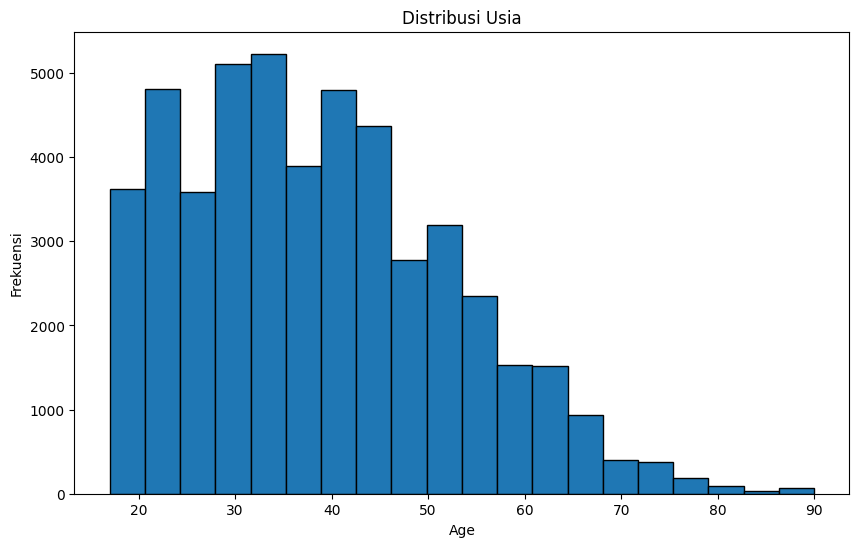

In [191]:
# Jawab 1.1 - Histrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df['age'], bins=20, edgecolor='black')

plt.title('Distribusi Usia')
plt.xlabel('Age')
plt.ylabel('Frekuensi')

plt.show()

In [192]:
# Menghitung jumlah setiap kategori
education_counts = df['education'].value_counts()

print(education_counts)

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


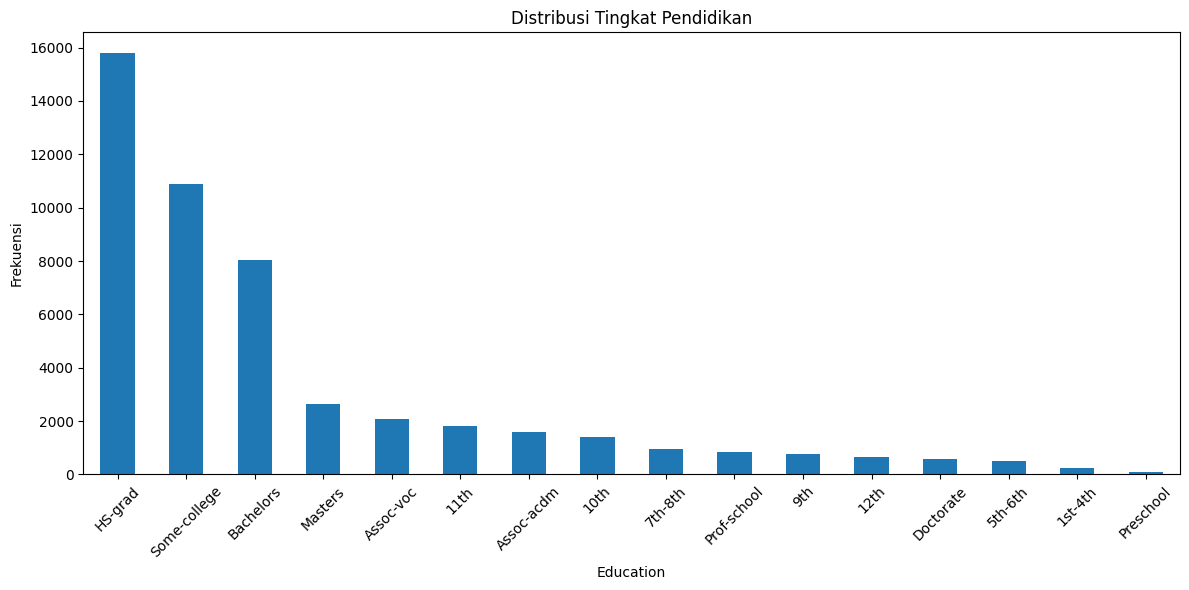

In [193]:
# Jawab 1.2 - Barchart
plt.figure(figsize=(12, 6))

education_counts.plot(kind='bar')

plt.title('Distribusi Tingkat Pendidikan')
plt.xlabel('Education')
plt.ylabel('Frekuensi')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [194]:
# Memahami dua variabel terlebih dahulu
df[['income', 'hours-per-week']].head()

,income,hours-per-week
0,<=50K,40
1,<=50K,13
2,<=50K,40
3,<=50K,40
4,<=50K,40


In [195]:
# Mengecek kategori income
df['income'].value_counts()

,count
income,
<=50K,37155
>50K,11687


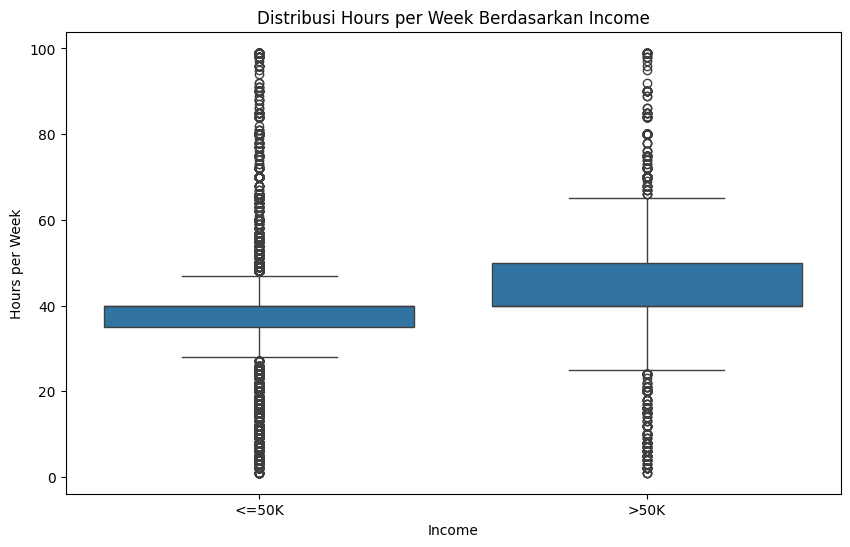

In [196]:
# Jawab 1.3 - Boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='income',
    y='hours-per-week'
)

plt.title('Distribusi Hours per Week Berdasarkan Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')

plt.show()

In [197]:
# Grouping berdasarkan age
age_capital = df.groupby('age')[['capital-gain', 'capital-loss']].mean()

age_capital.head()

,capital-gain,capital-loss
age,,
17,81.245378,33.302521
18,76.163573,37.852668
19,126.797721,42.579297
20,66.937107,35.743935
21,169.385949,40.899635


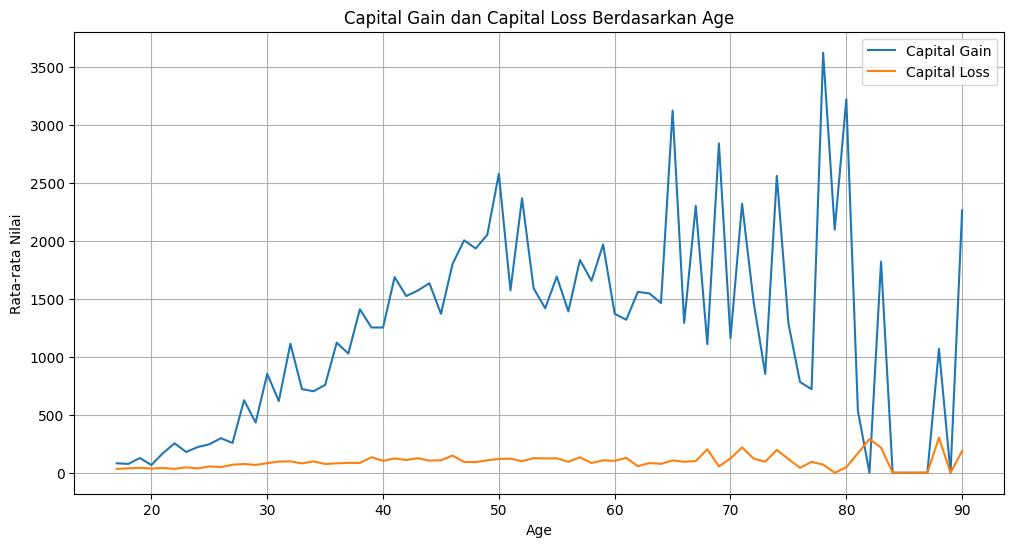

In [198]:
# Jawab 1.4 -
age_capital = df.groupby('age')[['capital-gain', 'capital-loss']].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    age_capital.index,
    age_capital['capital-gain'],
    label='Capital Gain'
)

plt.plot(
    age_capital.index,
    age_capital['capital-loss'],
    label='Capital Loss'
)

plt.title('Capital Gain dan Capital Loss Berdasarkan Age')
plt.xlabel('Age')
plt.ylabel('Rata-rata Nilai')
plt.legend()
plt.grid(True)

plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [199]:
# Menghitung outlier hours-per-week pada setiap kategori income

for kategori in df['income'].unique():
    data = df[df['income'] == kategori]['hours-per-week']

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    outlier = data[
        (data < batas_bawah) |
        (data > batas_atas)
    ]

    print(kategori, ":", len(outlier))

<=50K : 11706
>50K : 781


In [200]:
# Jawab dengan komentar python

'''
1. Fenomena apa yang terjadi pada distribusi age?

Distribusi variabel age cenderung mengalami positive skew atau right-skewed.
Sebagian besar data terkonsentrasi pada usia dewasa muda hingga menengah,
sedangkan jumlah data semakin sedikit pada usia yang lebih tinggi sehingga
membentuk ekor distribusi ke arah kanan.

2. Jika terdapat data yang hilang pada variabel age, strategi apa yang
Anda terapkan? Mengapa?

Jika terdapat missing value pada variabel age, saya akan menggunakan median
imputation. Median dipilih karena distribusi age cenderung right-skewed dan
lebih tahan terhadap pengaruh nilai ekstrem dibandingkan mean.

3. Berapa jumlah outlier pada setiap kategori income berkaitan
dengan hour-per-week? Kategori apa yang paling banyak memiliki outlier?

Berdasarkan perhitungan menggunakan metode IQR pada variabel hours-per-week,
kategori <=50K memiliki 11706 outlier, sedangkan kategori >50K memiliki
781 outlier. Dengan demikian, kategori income <=50K merupakan kategori
yang memiliki jumlah outlier paling banyak.

'''

'\n1. Fenomena apa yang terjadi pada distribusi age?\n\nDistribusi variabel age cenderung mengalami positive skew atau right-skewed.\nSebagian besar data terkonsentrasi pada usia dewasa muda hingga menengah,\nsedangkan jumlah data semakin sedikit pada usia yang lebih tinggi sehingga\nmembentuk ekor distribusi ke arah kanan.\n\n2. Jika terdapat data yang hilang pada variabel age, strategi apa yang \nAnda terapkan? Mengapa?\n\nJika terdapat missing value pada variabel age, saya akan menggunakan median\nimputation. Median dipilih karena distribusi age cenderung right-skewed dan\nlebih tahan terhadap pengaruh nilai ekstrem dibandingkan mean.\n\n3. Berapa jumlah outlier pada setiap kategori income berkaitan \ndengan hour-per-week? Kategori apa yang paling banyak memiliki outlier?\n\nBerdasarkan perhitungan menggunakan metode IQR pada variabel hours-per-week,\nkategori <=50K memiliki 11706 outlier, sedangkan kategori >50K memiliki\n781 outlier. Dengan demikian, kategori income <=50K merupaka

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [201]:
# Mengecek Sex terlebih dahulu
print(df['sex'].unique())
print(df['sex'].value_counts(dropna=False))

['Male' 'Female']
sex
Male      32650
Female    16192
Name: count, dtype: int64


In [202]:
# Encoding Sex
df['sex'] = df['sex'].map({
    'Female': 0,
    'Male': 1
})

df['sex'].value_counts()

,count
sex,
1,32650
0,16192


In [203]:
# Mengecek income terlebih dahulu
print(df['income'].unique())
print(df['income'].value_counts(dropna=False))

['<=50K' '>50K']
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [204]:
# Encoding income
df['income'] = df['income'].map({
    '<=50K': 0,
    '>50K': 1
})

df['income'].value_counts()

,count
income,
0,37155
1,11687


In [205]:
# Memvalidasi hasil dari kedua encoding.
# Karena jika encoding dijalankan 2 kali hasilnya akan jadi NaN.
print("Hasil encoding sex:")
print(df['sex'].value_counts())

print("\nHasil encoding income:")
print(df['income'].value_counts())

print("\nJumlah NaN:")
print(df[['sex', 'income']].isnull().sum())

Hasil encoding sex:
sex
1    32650
0    16192
Name: count, dtype: int64

Hasil encoding income:
income
0    37155
1    11687
Name: count, dtype: int64

Jumlah NaN:
sex       0
income    0
dtype: int64


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

In [206]:
# Variabel yang akan dianalisis
kolom_korelasi = [
    'age',
    'education-num',
    'hours-per-week',
    'capital-gain',
    'capital-loss',
    'income'
]
df[kolom_korelasi].head()

,age,education-num,hours-per-week,capital-gain,capital-loss,income
0,39,13,40,2174,0,0
1,50,13,13,0,0,0
2,38,9,40,0,0,0
3,53,7,40,0,0,0
4,28,13,40,0,0,0


In [207]:
# Mengitung korelasi
korelasi = df[kolom_korelasi].corr()

# Menampilkan korelasi
korelasi

,age,education-num,hours-per-week,capital-gain,capital-loss,income
age,1.000000,0.030940,0.071558,0.077229,0.056944,0.230369
education-num,0.030940,1.000000,0.143689,0.125146,0.080972,0.332613
hours-per-week,0.071558,0.143689,1.000000,0.082157,0.054467,0.227687
capital-gain,0.077229,0.125146,0.082157,1.000000,-0.031441,0.223013
capital-loss,0.056944,0.080972,0.054467,-0.031441,1.000000,0.147554
income,0.230369,0.332613,0.227687,0.223013,0.147554,1.000000


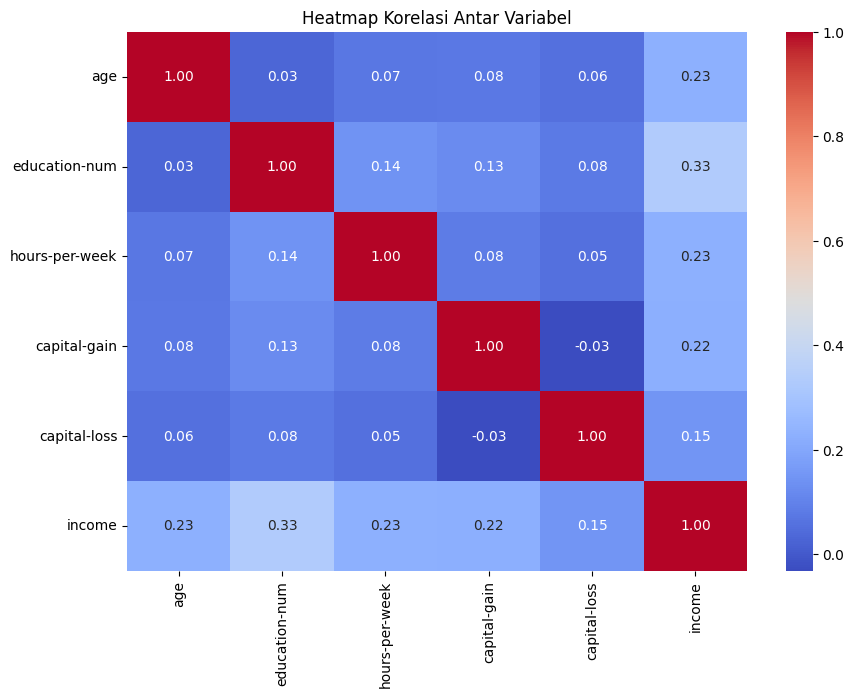

In [208]:
# Memvisualisasikan dengan heatmap supaya lebih mudah untuk dibaca
plt.figure(figsize=(10, 7))

sns.heatmap(
    korelasi,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

In [209]:
# Menampilkan korelasi terhadap target income
print("Korelasi terhadap Income:")
print(korelasi['income'].sort_values(ascending=False))

Korelasi terhadap Income:
income            1.000000
education-num     0.332613
age               0.230369
hours-per-week    0.227687
capital-gain      0.223013
capital-loss      0.147554
Name: income, dtype: float64


In [210]:
# Hasil analisis jelaskan pada cell ini
'''
Berdasarkan hasil analisis korelasi, seluruh variabel yang dianalisis memiliki korelasi positif
terhadap income. Karena income telah di-encoding menjadi 0 untuk <=50K dan 1 untuk >50K, korelasi
positif menunjukan bahwa peningkatan nilai variabel tersebut cenderung berkaitan dengan
kategori income >50K

- Education-num memiliki korelasi positif paling tinggi terhadap income, yaitu
sebesar 0.332613. Hal ini menunjukkan bahwa dari variabel yang dianalisis,
education-num memiliki hubungan linear paling kuat dengan income.

- Age memiliki korelasi sebesar 0.230369, hours-per-week sebesar 0.227687,
dan capital-gain sebesar 0.223013. Ketiganya menunjukkan hubungan positif
yang relatif lemah terhadap income.

- Capital-loss memiliki korelasi paling rendah terhadap income, yaitu sebesar
0.147554, sehingga hubungan linearnya terhadap income merupakan yang paling
lemah di antara variabel yang dianalisis.

Secara keseluruhan, tidak terdapat korelasi yang sangat kuat terhadap income
karena seluruh nilai korelasi berada di bawah 0.5. Selain itu, korelasi hanya
menunjukkan hubungan antarvariabel dan tidak membuktikan hubungan sebab-akibat.

'''

'\nBerdasarkan hasil analisis korelasi, seluruh variabel yang dianalisis memiliki korelasi positif\nterhadap income. Karena income telah di-encoding menjadi 0 untuk <=50K dan 1 untuk >50K, korelasi\npositif menunjukan bahwa peningkatan nilai variabel tersebut cenderung berkaitan dengan\nkategori income >50K\n\n- Education-num memiliki korelasi positif paling tinggi terhadap income, yaitu\nsebesar 0.332613. Hal ini menunjukkan bahwa dari variabel yang dianalisis,\neducation-num memiliki hubungan linear paling kuat dengan income.\n\n- Age memiliki korelasi sebesar 0.230369, hours-per-week sebesar 0.227687,\ndan capital-gain sebesar 0.223013. Ketiganya menunjukkan hubungan positif\nyang relatif lemah terhadap income.\n\n- Capital-loss memiliki korelasi paling rendah terhadap income, yaitu sebesar\n0.147554, sehingga hubungan linearnya terhadap income merupakan yang paling\nlemah di antara variabel yang dianalisis.\n\nSecara keseluruhan, tidak terdapat korelasi yang sangat kuat terhadap in

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [211]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


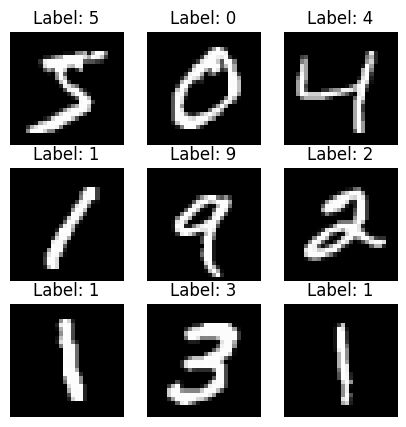

In [212]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

In [213]:
X_test

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

In [214]:
# Mengimport OpenCV
import cv2

In [215]:
# Membuat array kosong untuk menampung hasil upsampling
X_test_resized = np.empty(
    (X_test.shape[0], 32, 32),
    dtype=X_test.dtype
)

In [216]:
# Melakukan upsampling seluruh data test dari 28x28 menjadi 32x32
for i in range(X_test.shape[0]):
    X_test_resized[i] = cv2.resize(
        X_test[i],
        (32, 32),
        interpolation=cv2.INTER_LINEAR
    )

In [217]:
# Memeriksa perubahan ukuran data
print("Ukuran sebelum upsampling:", X_test.shape)
print("Ukuran setelah upsampling:", X_test_resized.shape)

Ukuran sebelum upsampling: (10000, 28, 28)
Ukuran setelah upsampling: (10000, 32, 32)


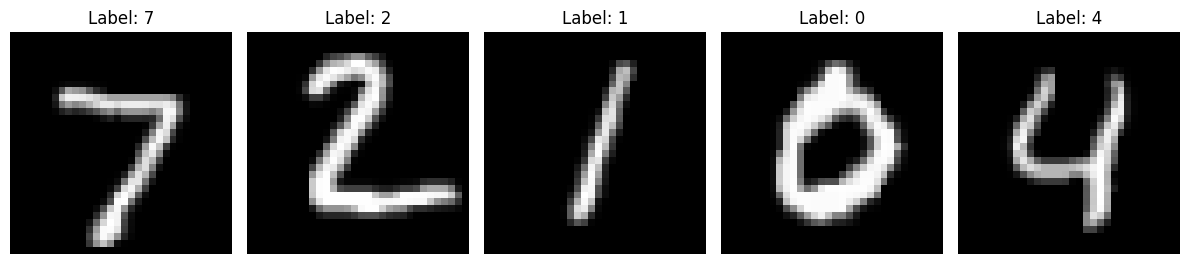

In [227]:
# Menampilkan 5 hasil upsampling
plt.figure(figsize=(12, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_resized[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [219]:
# Mengecek nilai sebelum normalisasi
print("Sebelum normalisasi:")
print("Nilai minimum:", X_test_resized.min())
print("Nilai maksimum:", X_test_resized.max())
print("Tipe data:", X_test_resized.dtype)

Sebelum normalisasi:
Nilai minimum: 0
Nilai maksimum: 255
Tipe data: uint8


In [220]:
# Melakukan normalisasi
X_test_normalized = X_test_resized.astype('float32') / 255.0

In [221]:
# Memverivikasi hasil normalisasi
print("\nSetelah normalisasi:")
print("Nilai minimum:", X_test_normalized.min())
print("Nilai maksimum:", X_test_normalized.max())
print("Tipe data:", X_test_normalized.dtype)
print("Shape:", X_test_normalized.shape)


Setelah normalisasi:
Nilai minimum: 0.0
Nilai maksimum: 1.0
Tipe data: float32
Shape: (10000, 32, 32)


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [228]:
# Membuat holder array kosong untuk menampung hasil flatten
X_test_flatten = np.empty(
    (X_test_normalized.shape[0], 32 * 32),
    dtype=X_test_normalized.dtype
)

In [229]:
# Mengubah setiap citra 32x32 menjadi array 1 dimensi
# dan memasukkannya ke holder
for i in range(X_test_normalized.shape[0]):
    X_test_flatten[i] = X_test_normalized[i].reshape(-1)

In [230]:
# Membandingkan shape sebelum dan sesudah flatten
print("Shape sebelum flatten:", X_test_normalized.shape)
print("Shape setelah flatten:", X_test_flatten.shape)


Shape sebelum flatten: (10000, 32, 32)
Shape setelah flatten: (10000, 1024)


In [231]:
# Menampilkan 9 data pertama hasil flatten
for i in range(9):
    print(f"\nData ke-{i+1}:")
    print(X_test_flatten[i])
    print("Shape:", X_test_flatten[i].shape)


Data ke-1:
[0. 0. 0. ... 0. 0. 0.]
Shape: (1024,)

Data ke-2:
[0. 0. 0. ... 0. 0. 0.]
Shape: (1024,)

Data ke-3:
[0. 0. 0. ... 0. 0. 0.]
Shape: (1024,)

Data ke-4:
[0. 0. 0. ... 0. 0. 0.]
Shape: (1024,)

Data ke-5:
[0. 0. 0. ... 0. 0. 0.]
Shape: (1024,)

Data ke-6:
[0. 0. 0. ... 0. 0. 0.]
Shape: (1024,)

Data ke-7:
[0. 0. 0. ... 0. 0. 0.]
Shape: (1024,)

Data ke-8:
[0. 0. 0. ... 0. 0. 0.]
Shape: (1024,)

Data ke-9:
[0. 0. 0. ... 0. 0. 0.]
Shape: (1024,)


In [232]:
print("Contoh shape satu data:", X_test_flatten[0].shape)
print("Jumlah data:", X_test_flatten.shape[0])

Contoh shape satu data: (1024,)
Jumlah data: 10000
